In [2]:
import sys
sys.path.append('../src')
from custom_functions import error_handling

In [3]:
try:
    # Core libraries
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    #Utils
    from dotenv import load_dotenv
    import os
    from pathlib import Path
    import json

    # Google Auth
    from google.oauth2 import service_account
    from google.cloud import bigquery
    import warnings
    warnings.filterwarnings("ignore")
    print('Libs imported')
except Exception as e:
    error_handling(e)

Libs imported


In [4]:
src_dir = Path('..')
try:
    load_dotenv(src_dir / '.env')
    creds_path = src_dir / os.getenv('GOOGLE_APPLICATION_CREDENTIALS')
    project = os.getenv('GOOGLE_CLOUD_PROJECT')
    credentials = service_account.Credentials.from_service_account_file(creds_path)
    bq_client = bigquery.Client(
        project=project,
        credentials=credentials
    )
    print('BigQuery client ready')
except Exception as e:
    error_handling(e)

BigQuery client ready


In [5]:
try:
    dataset_id = f"{project}.raw_data"
    dataset = bigquery.Dataset(dataset_id)
    dataset.location = "EU"
    dataset = bq_client.create_dataset(dataset, exists_ok=True)
    print(f"Dataset created: {dataset_id}")
except Exception as e:
    error_handling(e)

Dataset created: customer-segmention.raw_data


In [6]:
schemas_file = Path("../bigquery/schemas/raw_data.json")

with open(schemas_file) as f:
    fields = json.load(f)

In [7]:
schema_df = pd.DataFrame({'name':[field['name'] for field in fields],
             'type': [field['type'] for field in fields],
             'mode': [field['mode'] for field in fields]})

print('Number of columns:', len(schema_df['name']))
display(schema_df)

Number of columns: 27


,name,type,mode
0,ID,INTEGER,NULLABLE
1,Year_Birth,INTEGER,NULLABLE
2,Education,STRING,NULLABLE
3,Marital_Status,STRING,NULLABLE
4,Income,FLOAT,NULLABLE
5,Kidhome,INTEGER,NULLABLE
6,Teenhome,INTEGER,NULLABLE
7,Dt_Customer,DATE,NULLABLE
8,Recency,INTEGER,NULLABLE
9,MntWines,INTEGER,NULLABLE


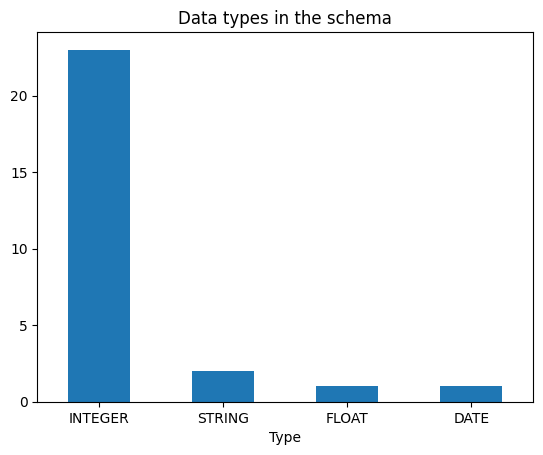

In [8]:
schema_df['type'].value_counts().plot(kind='bar')
plt.xlabel('Type')
plt.xticks(rotation=0)
plt.title('Data types in the schema')
plt.show()

In [9]:
from bq_table_creation import table_creation

In [10]:
synthetic_data = '../data/synthetic_marketing_campaign.parquet'
expanded_df = pd.read_parquet(synthetic_data)
expanded_df["Dt_Customer"] = pd.to_datetime(expanded_df["Dt_Customer"]).dt.date

In [23]:
table_creation(schemas_file, dataset_id, bq_client)

customer-segmention.raw_data.raw_data successfully created
customer-segmention:raw_data.raw_data | 27 fields | created: 2026-05-01 19:10:15.350000+00:00
------------------------------------------------------------------------------------------
Finished


In [53]:
table_id = 'raw_data'
full_table_id = f'{dataset_id}.{table_id}'
print(full_table_id)

customer-segmention.raw_data.raw_data


In [55]:
try:
    load_job = bq_client.load_table_from_dataframe(expanded_df, full_table_id)
    load_job.result()
    print(f"Loaded {load_job.output_rows:,} rows")
except Exception as e:
    error_handling(e)


Loaded 1,000,000 rows
